# Pricing Analysis & Optimization Framework

This notebook implements a comprehensive pricing analysis for product catalog. The analysis covers:
1. Data Preparation & Cleaning
2. Profitability, Competitive, Inventory, Sales, Returns, and Ads Analysis
3. Pricing Framework Design
4. Implementation & Recommendations
5. Visualization & Reporting

## Phase 1: Data Preparation & Cleaning

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load all CSV files
data_path = 'data/'

pricing_df = pd.read_csv(f'{data_path}Pricing_Data.csv')
competitor_df = pd.read_csv(f'{data_path}Competitor_Data.csv')
inventory_df = pd.read_csv(f'{data_path}Inventory_Health.csv')
sales_df = pd.read_csv(f'{data_path}Historical_Sales.csv')
ads_df = pd.read_csv(f'{data_path}Ads_Performance.csv')
returns_df = pd.read_csv(f'{data_path}Returns_Data.csv')

print("Data loaded successfully!")
print(f"\nDataset shapes:")
print(f"Pricing Data: {pricing_df.shape}")
print(f"Competitor Data: {competitor_df.shape}")
print(f"Inventory Health: {inventory_df.shape}")
print(f"Historical Sales: {sales_df.shape}")
print(f"Ads Performance: {ads_df.shape}")
print(f"Returns Data: {returns_df.shape}")

Data loaded successfully!

Dataset shapes:
Pricing Data: (50, 11)
Competitor Data: (50, 5)
Inventory Health: (50, 28)
Historical Sales: (4243, 7)
Ads Performance: (12777, 25)
Returns Data: (50, 5)


### Step 1.2: Clean Pricing Data

In [3]:
# Display raw pricing data
print("Raw Pricing Data:")
pricing_df.head()

Raw Pricing Data:


,SKU,Product_description,Product Role,Country_of_Origin,FBA Fee,Storage Fee,Handling_Cost,Cost,Current_Price,Minimum_Acceptable_Margin_%,Target_Gross_Margin_%
0,MN-01,Rectangle Tray -14 x 10 Inch - Pk of 25,Core,India,$15.11,$0.44,$0.75,$16.00,$38.90,20%,35%
1,MN-02,Rectangle Tray -12x10 - Pk of 25,Core,India,$13.55,$0.30,$0.75,$12.00,$33.90,20%,35%
2,MN-03,Oval Tray -15x10 Inch - Pk of 25,Core,India,$13.94,$0.34,$0.75,$15.00,$34.90,20%,35%
3,MN-04,Oval Tray - 13x9 Inch - pk of 25,Core,India,$12.89,$0.30,$0.75,$12.00,$29.90,20%,35%
4,MN-05,Christmas Tray - 17x12 Inch - Pk of 5,Seasonal,India,$11.80,$0.22,$0.75,$13.00,$21.90,25%,45%


In [4]:
def clean_price(value):
    """Remove $ and convert to float"""
    if pd.isna(value) or value == '':
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    return float(str(value).replace('$', '').replace(',', '').strip())

def clean_percentage(value):
    """Remove % and convert to float"""
    if pd.isna(value) or value == '':
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    return float(str(value).replace('%', '').strip())

# Clean price columns
price_columns = ['FBA Fee', 'Storage Fee', 'Handling_Cost', 'Cost', 'Current_Price']
for col in price_columns:
    pricing_df[col] = pricing_df[col].apply(clean_price)

# Clean percentage columns
pct_columns = ['Minimum_Acceptable_Margin_%', 'Target_Gross_Margin_%']
for col in pct_columns:
    pricing_df[col] = pricing_df[col].apply(clean_percentage)

# Handle missing Handling_Cost (MN-38) - use $0.75 default
pricing_df['Handling_Cost'] = pricing_df['Handling_Cost'].fillna(0.75)

print("Pricing Data after cleaning:")
print(pricing_df.info())
print("\nMissing values:")
print(pricing_df.isnull().sum())

Pricing Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SKU                          50 non-null     object 
 1   Product_description          50 non-null     object 
 2   Product Role                 50 non-null     object 
 3   Country_of_Origin            50 non-null     object 
 4   FBA Fee                      50 non-null     float64
 5   Storage Fee                  50 non-null     float64
 6   Handling_Cost                50 non-null     float64
 7   Cost                         50 non-null     float64
 8   Current_Price                50 non-null     float64
 9   Minimum_Acceptable_Margin_%  50 non-null     float64
 10  Target_Gross_Margin_%        50 non-null     float64
dtypes: float64(7), object(4)
memory usage: 4.4+ KB
None

Missing values:
SKU                            0
Product

In [5]:
# Verify cleaned pricing data
pricing_df.head(10)

,SKU,Product_description,Product Role,Country_of_Origin,FBA Fee,Storage Fee,Handling_Cost,Cost,Current_Price,Minimum_Acceptable_Margin_%,Target_Gross_Margin_%
0,MN-01,Rectangle Tray -14 x 10 Inch - Pk of 25,Core,India,15.11,0.44,0.75,16.00,38.90,20.00,35.00
1,MN-02,Rectangle Tray -12x10 - Pk of 25,Core,India,13.55,0.30,0.75,12.00,33.90,20.00,35.00
2,MN-03,Oval Tray -15x10 Inch - Pk of 25,Core,India,13.94,0.34,0.75,15.00,34.90,20.00,35.00
3,MN-04,Oval Tray - 13x9 Inch - pk of 25,Core,India,12.89,0.30,0.75,12.00,29.90,20.00,35.00
4,MN-05,Christmas Tray - 17x12 Inch - Pk of 5,Seasonal,India,11.80,0.22,0.75,13.00,21.90,25.00,45.00
5,MN-06,Star Tray - 14 Inch - Pk of 5,Seasonal,India,8.50,0.12,0.75,5.00,14.95,25.00,45.00
6,MN-07,15 Round plate - pk of 10,Core,India,17.85,0.27,0.75,11.00,34.90,20.00,35.00
7,MN-08,10 Inch Heart Plates - pk of 25,Seasonal,India,12.11,0.25,0.75,13.00,29.90,25.00,45.00
8,MN-09,6 Inch Heart Plates - pk of 25,Seasonal,India,8.08,0.09,0.75,6.00,14.90,25.00,45.00
9,MN-10,9x6 Rectangle - pk of 25,Core,India,9.52,0.13,0.75,7.00,19.90,20.00,35.00


### Step 1.3: Clean Competitor Data

In [6]:
# Display raw competitor data
print("Raw Competitor Data:")
competitor_df.head()

Raw Competitor Data:


,SKU,Avg_Competitor_Price,Lowest_Competitor_Price,Highest_Competitor_Price,Competitor_Count
0,MN-01,$36.90,$31.95,$44.90,9
1,MN-02,$32.50,$27.90,$39.95,8
2,MN-03,$35.20,$29.99,$42.50,7
3,MN-04,$28.40,$24.50,$35.90,6
4,MN-05,$23.90,$18.95,-,3


In [7]:
def clean_competitor_price(value):
    """Handle special cases in competitor prices"""
    if pd.isna(value) or value == '' or value == '-' or value == 'NA':
        return np.nan
    if isinstance(value, (int, float)):
        return float(value) if float(value) > 0 else np.nan
    cleaned = str(value).replace('$', '').replace(',', '').strip()
    try:
        result = float(cleaned)
        return result if result > 0 else np.nan
    except:
        return np.nan

# Clean price columns
comp_price_cols = ['Avg_Competitor_Price', 'Lowest_Competitor_Price', 'Highest_Competitor_Price']
for col in comp_price_cols:
    competitor_df[col] = competitor_df[col].apply(clean_competitor_price)

# Handle "NA" in Avg_Competitor_Price (MN-33) - use average of Low/High
# Handle "$0.00" in Avg_Competitor_Price (MN-44) - use Lowest price
# Handle "-" in Highest_Competitor_Price (MN-05) - use Avg

for idx, row in competitor_df.iterrows():
    # If Avg is missing, calculate from Low and High
    if pd.isna(row['Avg_Competitor_Price']):
        low = row['Lowest_Competitor_Price']
        high = row['Highest_Competitor_Price']
        if pd.notna(low) and pd.notna(high):
            competitor_df.at[idx, 'Avg_Competitor_Price'] = (low + high) / 2
        elif pd.notna(low):
            competitor_df.at[idx, 'Avg_Competitor_Price'] = low
    
    # If High is missing, use Avg
    if pd.isna(row['Highest_Competitor_Price']) and pd.notna(row['Avg_Competitor_Price']):
        competitor_df.at[idx, 'Highest_Competitor_Price'] = row['Avg_Competitor_Price']

print("Competitor Data after cleaning:")
print(competitor_df.info())
print("\nMissing values:")
print(competitor_df.isnull().sum())
print("\nSKUs with special handling:")
print(competitor_df[competitor_df['SKU'].isin(['MN-33', 'MN-44', 'MN-05'])])

Competitor Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SKU                       50 non-null     object 
 1   Avg_Competitor_Price      50 non-null     float64
 2   Lowest_Competitor_Price   50 non-null     float64
 3   Highest_Competitor_Price  50 non-null     float64
 4   Competitor_Count          50 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 2.1+ KB
None

Missing values:
SKU                         0
Avg_Competitor_Price        0
Lowest_Competitor_Price     0
Highest_Competitor_Price    0
Competitor_Count            0
dtype: int64

SKUs with special handling:
      SKU  Avg_Competitor_Price  Lowest_Competitor_Price  \
4   MN-05                 23.90                    18.95   
32  MN-33                 27.92                    21.95   
43  MN-44                

### Step 1.4: Clean Inventory Health Data

In [8]:
# Display raw inventory data
print("Raw Inventory Data:")
inventory_df.head()

Raw Inventory Data:


,SKU,condition,total-inventory,available,inbound-shipped,inbound-received,reserved-quantity,unfulfillable-quantity,inv-age-0-to-30-days,inv-age-31-to-60-days,inv-age-61-to-90-days,inv-age-181-to-330-days,inv-age-331-to-365-days,inv-age-365-plus-days,currency,units-shipped-t7,units-shipped-t30,units-shipped-t60,units-shipped-t90,sell-through,item-volume,volume-unit-measurement,storage-type,storage-volume,marketplace,days-of-supply,weeks-of-cover-t30,weeks-of-cover-t90
0,MN-01,New,382.00,264,40,9,68,1,12,261,56,0,0,0,USD,59,203,386,574,1.33,0.55,cubic feet,Standard,144.35,US,47,6,7
1,MN-02,New,306.00,206,80,2,18,0,127,91,17,0,0,0,USD,29,155,261,417,1.56,0.37,cubic feet,Standard,77.04,US,85,7,8
2,MN-03,New,139.00,95,40,0,3,1,42,8,62,0,0,0,USD,13,67,116,179,1.16,0.43,cubic feet,Standard,40.46,US,83,8,9
3,MN-04,New,171.00,70,80,8,13,0,3,84,0,0,0,0,USD,18,71,128,187,1.65,0.38,cubic feet,Standard,26.29,US,99,8,10
4,MN-05,New,283.00,0,0,49,234,0,53,141,0,0,0,0,USD,249,491,543,557,1.47,0.27,cubic feet,Standard,0.00,US,145,0,1


In [9]:
# Handle missing total-inventory (MN-19, MN-39) - calculate from components
# total-inventory = available + inbound-shipped + inbound-received + reserved-quantity + unfulfillable-quantity

# Check for missing values
print("Missing total-inventory:")
print(inventory_df[inventory_df['total-inventory'].isna()][['SKU', 'total-inventory', 'available', 'inbound-shipped', 
                                                            'inbound-received', 'reserved-quantity', 'unfulfillable-quantity']])

# Calculate total inventory for missing values
for idx, row in inventory_df.iterrows():
    if pd.isna(row['total-inventory']):
        total = (row['available'] + row['inbound-shipped'] + row['inbound-received'] + 
                 row['reserved-quantity'] + row['unfulfillable-quantity'])
        inventory_df.at[idx, 'total-inventory'] = total

print("\nInventory Data after cleaning:")
print(inventory_df.info())
print("\nMissing values:")
print(inventory_df.isnull().sum().sum())

Missing total-inventory:
      SKU  total-inventory  available  inbound-shipped  inbound-received  \
18  MN-19              NaN        342                0                 1   
38  MN-39              NaN         22              216                 0   

    reserved-quantity  unfulfillable-quantity  
18                115                       2  
38                 36                       0  

Inventory Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SKU                      50 non-null     object 
 1   condition                50 non-null     object 
 2   total-inventory          50 non-null     float64
 3   available                50 non-null     int64  
 4   inbound-shipped          50 non-null     int64  
 5   inbound-received         50 non-null     int64  
 6   reserved-quantity        50 no

### Step 1.5: Clean Historical Sales Data

In [10]:
# Display raw sales data sample
print("Raw Sales Data:")
sales_df.head()

Raw Sales Data:


,Date,SKU,Sessions - Total,Page Views - Total,Units Ordered,Ordered Product Sales,Total Order Items
0,2025-09-01,MN-01,22.00,32.00,6.00,228.10,5.00
1,2025-09-01,MN-02,28.00,33.00,5.00,158.96,5.00
2,2025-09-01,MN-03,9.00,12.00,2.00,81.35,2.00
3,2025-09-01,MN-07,31.00,41.00,2.00,70.11,2.00
4,2025-09-01,MN-09,24.00,32.00,2.00,32.26,1.00


In [11]:
# Parse Date column (handle mixed formats)
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')
sales_df = sales_df.dropna(subset=['Date'])  # Remove rows with invalid dates

# Check for duplicates (some SKUs appear twice per day)
print(f"Total rows before dedup: {len(sales_df)}")
duplicates = sales_df.groupby(['Date', 'SKU']).size().reset_index(name='count')
print(f"Duplicate date-SKU combinations: {len(duplicates[duplicates['count'] > 1])}")

# Aggregate daily data per SKU (sum metrics)
sales_df = sales_df.groupby(['Date', 'SKU']).agg({
    'Sessions - Total': 'sum',
    'Page Views - Total': 'sum',
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum',
    'Total Order Items': 'sum'
}).reset_index()

print(f"Total rows after dedup: {len(sales_df)}")
print(f"\nDate range: {sales_df['Date'].min()} to {sales_df['Date'].max()}")
print(f"Unique SKUs: {sales_df['SKU'].nunique()}")

Total rows before dedup: 4212
Duplicate date-SKU combinations: 200
Total rows after dedup: 4012

Date range: 2025-09-01 00:00:00 to 2025-11-30 00:00:00
Unique SKUs: 50


### Step 1.6: Clean Ads Performance Data

In [12]:
# Display raw ads data sample
print("Raw Ads Data:")
ads_df.head()

Raw Ads Data:


,date,SKU,impressions,clicks,costPerClick,clickThroughRate,cost,spend,currency-code,purchases1d,purchases7d,purchases14d,purchases30d,unitsSoldClicks1d,unitsSoldClicks7d,unitsSoldClicks14d,unitsSoldClicks30d,sales1d,sales7d,sales14d,sales30d,acosClicks7d,acosClicks14d,roasClicks7d,roasClicks14d
0,2025-09-01,MN-16,2016,14,2.00,0.69,27.97,27.97,USD,1,1,1,1,1,1,1,1,18.89,18.89,18.89,18.89,148.07,148.07,0.68,0.68
1,2025-09-01,MN-15,1810,33,2.06,1.82,68.06,68.06,USD,4,6,6,6,4,6,6,6,107.45,161.31,161.31,161.31,42.19,42.19,2.37,2.37
2,2025-09-01,MN-14,613,9,2.85,1.47,25.65,25.65,USD,0,1,1,1,0,1,1,1,0.00,90.98,90.98,90.98,28.19,28.19,3.55,3.55
3,2025-09-01,MN-17,1271,3,5.62,0.24,16.86,16.86,USD,2,2,2,2,9,9,9,9,274.41,274.41,274.41,274.41,6.14,6.14,16.28,16.28
4,2025-09-01,MN-25,1036,10,4.34,0.96,43.40,43.40,USD,1,3,3,3,2,8,8,8,218.30,851.24,851.24,851.24,5.10,5.10,19.61,19.61


In [13]:
# Parse date column (handle mixed formats)
ads_df['date'] = pd.to_datetime(ads_df['date'], errors='coerce')
ads_df = ads_df.dropna(subset=['date'])  # Remove rows with invalid dates

# Handle empty costPerClick values - set to 0 for no clicks
ads_df['costPerClick'] = ads_df['costPerClick'].fillna(0)

# Handle empty ACOS/ROAS values (infinite or undefined when no sales)
ads_df['acosClicks7d'] = ads_df['acosClicks7d'].fillna(0)
ads_df['acosClicks14d'] = ads_df['acosClicks14d'].fillna(0)
ads_df['roasClicks7d'] = ads_df['roasClicks7d'].fillna(0)
ads_df['roasClicks14d'] = ads_df['roasClicks14d'].fillna(0)

print("Ads Data after cleaning:")
print(ads_df.info())
print(f"\nDate range: {ads_df['date'].min()} to {ads_df['date'].max()}")
print(f"Unique SKUs with ads: {ads_df['SKU'].nunique()}")

Ads Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 12771 entries, 0 to 12776
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                12771 non-null  datetime64[ns]
 1   SKU                 12771 non-null  object        
 2   impressions         12771 non-null  int64         
 3   clicks              12771 non-null  int64         
 4   costPerClick        12771 non-null  float64       
 5   clickThroughRate    12709 non-null  float64       
 6   cost                12771 non-null  float64       
 7   spend               12771 non-null  float64       
 8   currency-code       12771 non-null  object        
 9   purchases1d         12771 non-null  int64         
 10  purchases7d         12771 non-null  int64         
 11  purchases14d        12771 non-null  int64         
 12  purchases30d        12771 non-null  int64         
 13  unitsSoldClicks1d   12771 

### Step 1.7: Clean Returns Data

In [14]:
# Display raw returns data
print("Raw Returns Data:")
returns_df.head()

Raw Returns Data:


,SKU,Return Quantity \n(Last 7 days),Return Quantity \n(Last 30 days),Return Quantity \n(Last 60 days),Return Quantity \n(Last 90 days)
0,MN-01,0,9,18,26
1,MN-02,0,4,14,24
2,MN-03,1,4,10,13
3,MN-04,1,4,6,16
4,MN-09,0,2,7,11


In [15]:
# Clean column names
returns_df.columns = ['SKU', 'Returns_7d', 'Returns_30d', 'Returns_60d', 'Returns_90d']

# Handle "-" values in Return Quantity (MN-17)
def clean_returns(value):
    if pd.isna(value) or value == '-' or value == '':
        return 0
    return int(value)

for col in ['Returns_7d', 'Returns_30d', 'Returns_60d', 'Returns_90d']:
    returns_df[col] = returns_df[col].apply(clean_returns)

print("Returns Data after cleaning:")
print(returns_df.info())
print(f"\nTotal SKUs in returns data: {len(returns_df)}")

# Cross-reference with Pricing_Data
pricing_skus = set(pricing_df['SKU'])
returns_skus = set(returns_df['SKU'])
missing_in_returns = pricing_skus - returns_skus
print(f"SKUs in pricing but not in returns: {missing_in_returns}")

Returns Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SKU          50 non-null     object
 1   Returns_7d   50 non-null     int64 
 2   Returns_30d  50 non-null     int64 
 3   Returns_60d  50 non-null     int64 
 4   Returns_90d  50 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.1+ KB
None

Total SKUs in returns data: 50
SKUs in pricing but not in returns: set()


## Phase 2: Data Analysis & Insights

### Step 2.1: Profitability Analysis

In [16]:
# Calculate current margins for each SKU
pricing_df['Total_Cost'] = (pricing_df['Cost'] + pricing_df['FBA Fee'] + 
                            pricing_df['Storage Fee'] + pricing_df['Handling_Cost'])

pricing_df['Current_Margin_%'] = ((pricing_df['Current_Price'] - pricing_df['Total_Cost']) / 
                                   pricing_df['Current_Price'] * 100)

pricing_df['Current_Margin_$'] = pricing_df['Current_Price'] - pricing_df['Total_Cost']

# Flag SKUs based on margin health
def classify_margin_health(row):
    if row['Current_Margin_%'] < row['Minimum_Acceptable_Margin_%']:
        return 'CRITICAL'
    elif row['Current_Margin_%'] < row['Target_Gross_Margin_%']:
        return 'OPPORTUNITY'
    else:
        return 'HEALTHY'

pricing_df['Margin_Health'] = pricing_df.apply(classify_margin_health, axis=1)

print("Margin Health Distribution:")
print(pricing_df['Margin_Health'].value_counts())

# Display critical SKUs
print("\nCRITICAL SKUs (below minimum margin):")
critical_skus = pricing_df[pricing_df['Margin_Health'] == 'CRITICAL'][[
    'SKU', 'Product_description', 'Current_Price', 'Total_Cost', 
    'Current_Margin_%', 'Minimum_Acceptable_Margin_%', 'Target_Gross_Margin_%'
]]
print(critical_skus)

Margin Health Distribution:
Margin_Health
CRITICAL       42
OPPORTUNITY     8
Name: count, dtype: int64

CRITICAL SKUs (below minimum margin):
      SKU                       Product_description  Current_Price  \
0   MN-01  Rectangle Tray -14 x 10 Inch - Pk of  25          38.90   
2   MN-03         Oval Tray -15x10 Inch - Pk of  25          34.90   
3   MN-04          Oval Tray - 13x9 Inch - pk of 25          29.90   
4   MN-05     Christmas Tray - 17x12 Inch - Pk of 5          21.90   
5   MN-06             Star Tray - 14 Inch - Pk of 5          14.95   
6   MN-07                 15 Round plate - pk of 10          34.90   
7   MN-08           10 Inch Heart Plates - pk of 25          29.90   
8   MN-09            6 Inch Heart Plates - pk of 25          14.90   
9   MN-10                  9x6 Rectangle - pk of 25          19.90   
10  MN-11          Oval Tray - 13x9 Inch - pk of 10          16.90   
11  MN-12       13 inch Round DEEP plate - pk of 10          19.90   
13  MN-14        

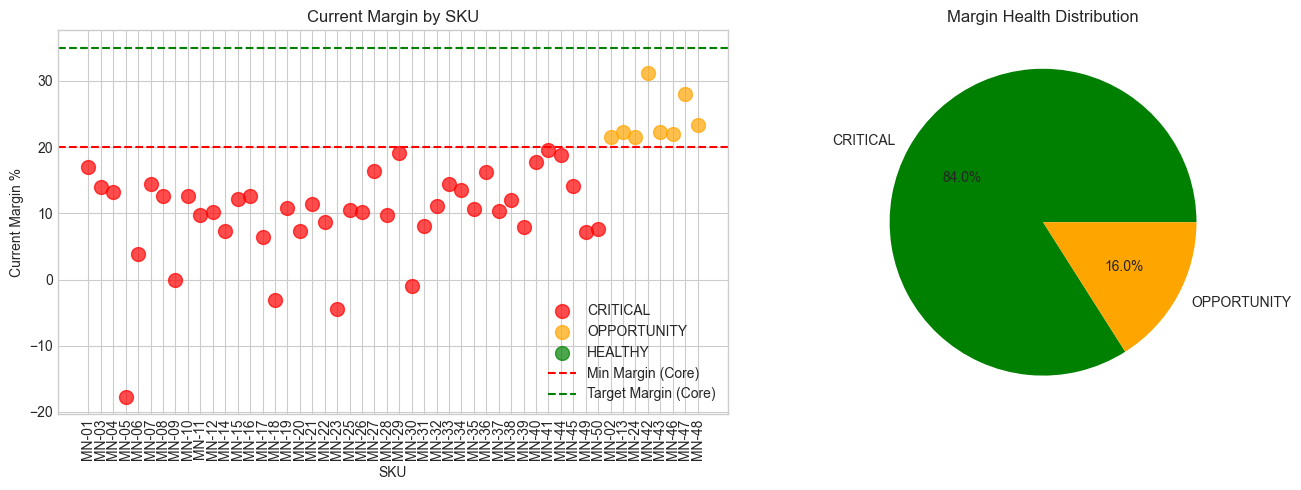

In [17]:
# Margin analysis visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Margin distribution
ax1 = axes[0]
colors = {'CRITICAL': 'red', 'OPPORTUNITY': 'orange', 'HEALTHY': 'green'}
for health, color in colors.items():
    subset = pricing_df[pricing_df['Margin_Health'] == health]
    ax1.scatter(subset['SKU'], subset['Current_Margin_%'], c=color, label=health, s=100, alpha=0.7)

ax1.axhline(y=20, color='red', linestyle='--', label='Min Margin (Core)')
ax1.axhline(y=35, color='green', linestyle='--', label='Target Margin (Core)')
ax1.set_xlabel('SKU')
ax1.set_ylabel('Current Margin %')
ax1.set_title('Current Margin by SKU')
ax1.legend()
ax1.tick_params(axis='x', rotation=90)

# Margin health pie chart
ax2 = axes[1]
health_counts = pricing_df['Margin_Health'].value_counts()
ax2.pie(health_counts.values, labels=health_counts.index, autopct='%1.1f%%', 
        colors=['green', 'orange', 'red'])
ax2.set_title('Margin Health Distribution')

plt.tight_layout()
plt.savefig('margin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.2: Competitive Position Analysis

In [18]:
# Merge pricing with competitor data
comp_analysis = pricing_df.merge(competitor_df, on='SKU', how='left')

# Calculate price differentials
comp_analysis['Price_vs_Avg'] = comp_analysis['Current_Price'] - comp_analysis['Avg_Competitor_Price']
comp_analysis['Price_vs_Low'] = comp_analysis['Current_Price'] - comp_analysis['Lowest_Competitor_Price']
comp_analysis['Price_vs_High'] = comp_analysis['Current_Price'] - comp_analysis['Highest_Competitor_Price']

# Calculate percentage difference from average
comp_analysis['Price_vs_Avg_%'] = ((comp_analysis['Current_Price'] - comp_analysis['Avg_Competitor_Price']) / 
                                    comp_analysis['Avg_Competitor_Price'] * 100)

# Classify competitive position
def classify_competitive_position(row):
    if pd.isna(row['Avg_Competitor_Price']):
        return 'Unknown'
    pct_diff = row['Price_vs_Avg_%']
    if pct_diff < -5:
        return 'Below Market'
    elif pct_diff > 5:
        return 'Above Market'
    else:
        return 'At Market'

comp_analysis['Competitive_Position'] = comp_analysis.apply(classify_competitive_position, axis=1)

print("Competitive Position Distribution:")
print(comp_analysis['Competitive_Position'].value_counts())

# Display SKUs above market
print("\nSKUs Above Market (>5% above avg competitor):")
above_market = comp_analysis[comp_analysis['Competitive_Position'] == 'Above Market'][[
    'SKU', 'Current_Price', 'Avg_Competitor_Price', 'Price_vs_Avg_%', 'Competitor_Count'
]].sort_values('Price_vs_Avg_%', ascending=False)
print(above_market)

Competitive Position Distribution:
Competitive_Position
At Market       34
Below Market    14
Above Market     2
Name: count, dtype: int64

SKUs Above Market (>5% above avg competitor):
     SKU  Current_Price  Avg_Competitor_Price  Price_vs_Avg_%  \
0  MN-01          38.90                 36.90            5.42   
3  MN-04          29.90                 28.40            5.28   

   Competitor_Count  
0                 9  
3                 6  


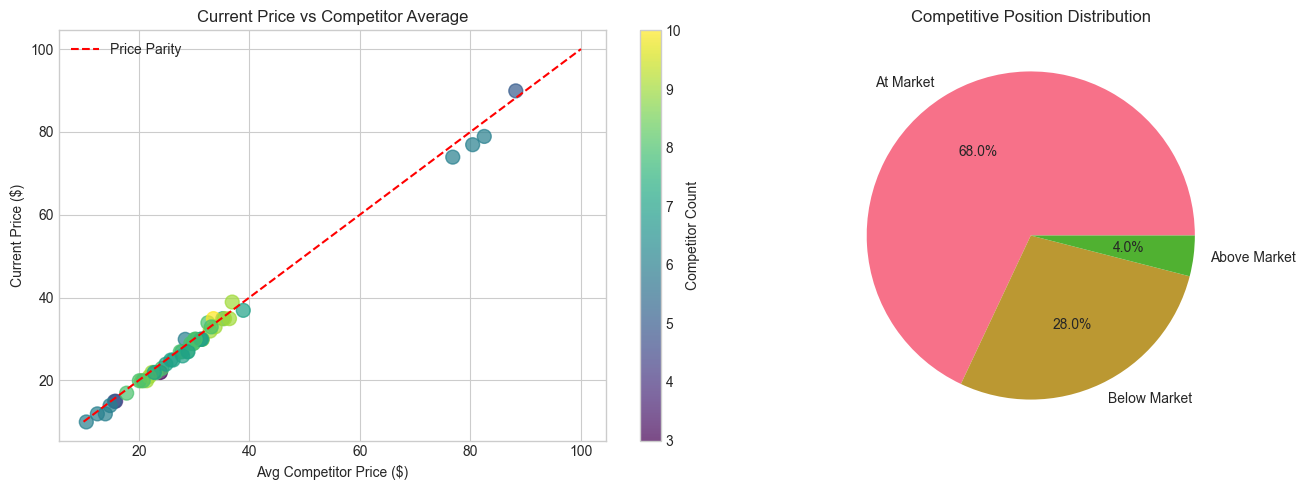

In [19]:
# Competitive position visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price comparison scatter
ax1 = axes[0]
valid_comp = comp_analysis[comp_analysis['Avg_Competitor_Price'].notna()]
ax1.scatter(valid_comp['Avg_Competitor_Price'], valid_comp['Current_Price'], 
            c=valid_comp['Competitor_Count'], cmap='viridis', s=100, alpha=0.7)
ax1.plot([10, 100], [10, 100], 'r--', label='Price Parity')
ax1.set_xlabel('Avg Competitor Price ($)')
ax1.set_ylabel('Current Price ($)')
ax1.set_title('Current Price vs Competitor Average')
ax1.legend()
cbar = plt.colorbar(ax1.collections[0], ax=ax1)
cbar.set_label('Competitor Count')

# Competitive position pie
ax2 = axes[1]
pos_counts = comp_analysis['Competitive_Position'].value_counts()
ax2.pie(pos_counts.values, labels=pos_counts.index, autopct='%1.1f%%')
ax2.set_title('Competitive Position Distribution')

plt.tight_layout()
plt.savefig('competitive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.3: Inventory Health Analysis

In [20]:
# Categorize inventory status
def classify_inventory_status(row):
    if row['available'] < 50 and row['weeks-of-cover-t30'] < 2:
        return 'Stockout Risk'
    elif row['weeks-of-cover-t30'] < 4:
        return 'Low Stock'
    elif row['weeks-of-cover-t30'] <= 12:
        return 'Healthy'
    else:
        return 'Overstocked'

inventory_df['Inventory_Status'] = inventory_df.apply(classify_inventory_status, axis=1)

# Calculate inventory pressure score (-1 to 1, negative = need to move, positive = can hold)
def calculate_inventory_pressure(row):
    woc = row['weeks-of-cover-t30']
    if woc <= 2:
        return 0.5  # Stockout risk - raise price
    elif woc <= 4:
        return 0.25
    elif woc <= 8:
        return 0
    elif woc <= 12:
        return -0.25
    else:
        return -0.5  # Overstocked - lower price

inventory_df['Inventory_Pressure'] = inventory_df.apply(calculate_inventory_pressure, axis=1)

print("Inventory Status Distribution:")
print(inventory_df['Inventory_Status'].value_counts())

# Display stockout risk SKUs
print("\nStockout Risk SKUs:")
stockout_risk = inventory_df[inventory_df['Inventory_Status'] == 'Stockout Risk'][[
    'SKU', 'available', 'total-inventory', 'weeks-of-cover-t30', 'units-shipped-t30'
]]
print(stockout_risk)

Inventory Status Distribution:
Inventory_Status
Healthy          38
Low Stock         6
Stockout Risk     3
Overstocked       3
Name: count, dtype: int64

Stockout Risk SKUs:
      SKU  available  total-inventory  weeks-of-cover-t30  units-shipped-t30
4   MN-05          0           283.00                   0                491
5   MN-06          1            21.00                   0                131
20  MN-21          2            18.00                   0                235


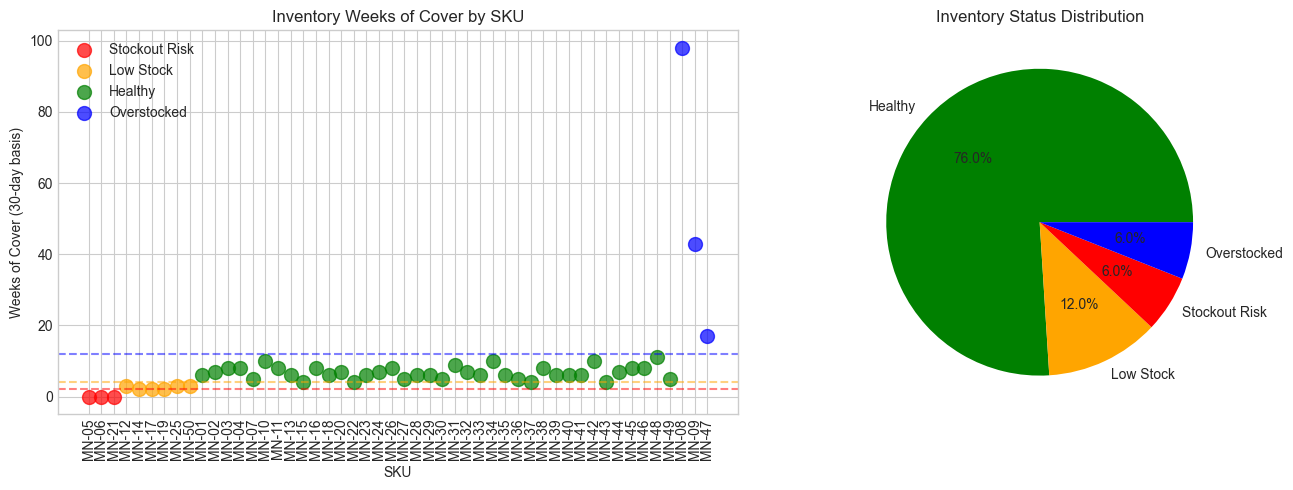

In [21]:
# Inventory health visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weeks of cover distribution
ax1 = axes[0]
status_colors = {'Stockout Risk': 'red', 'Low Stock': 'orange', 'Healthy': 'green', 'Overstocked': 'blue'}
for status, color in status_colors.items():
    subset = inventory_df[inventory_df['Inventory_Status'] == status]
    ax1.scatter(subset['SKU'], subset['weeks-of-cover-t30'], c=color, label=status, s=100, alpha=0.7)

ax1.axhline(y=2, color='red', linestyle='--', alpha=0.5)
ax1.axhline(y=4, color='orange', linestyle='--', alpha=0.5)
ax1.axhline(y=12, color='blue', linestyle='--', alpha=0.5)
ax1.set_xlabel('SKU')
ax1.set_ylabel('Weeks of Cover (30-day basis)')
ax1.set_title('Inventory Weeks of Cover by SKU')
ax1.legend()
ax1.tick_params(axis='x', rotation=90)

# Inventory status pie
ax2 = axes[1]
inv_counts = inventory_df['Inventory_Status'].value_counts()
ax2.pie(inv_counts.values, labels=inv_counts.index, autopct='%1.1f%%',
        colors=['green', 'orange', 'red', 'blue'])
ax2.set_title('Inventory Status Distribution')

plt.tight_layout()
plt.savefig('inventory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.4: Sales Velocity Analysis

In [22]:
# Aggregate sales data by SKU
sales_summary = sales_df.groupby('SKU').agg({
    'Units Ordered': 'sum',
    'Ordered Product Sales': 'sum',
    'Sessions - Total': 'sum',
    'Page Views - Total': 'sum',
    'Total Order Items': 'sum'
}).reset_index()

# Rename columns
sales_summary.columns = ['SKU', 'Total_Units_90d', 'Total_Sales_90d', 'Total_Sessions_90d', 
                         'Total_PageViews_90d', 'Total_Orders_90d']

# Calculate derived metrics
days_in_period = (sales_df['Date'].max() - sales_df['Date'].min()).days + 1
sales_summary['Avg_Daily_Units'] = sales_summary['Total_Units_90d'] / days_in_period
sales_summary['Conversion_Rate'] = (sales_summary['Total_Units_90d'] / 
                                     sales_summary['Total_Sessions_90d'] * 100)

# Calculate trend (compare last 30 days vs first 30 days)
date_cutoff_early = sales_df['Date'].min() + pd.Timedelta(days=30)
date_cutoff_late = sales_df['Date'].max() - pd.Timedelta(days=30)

early_sales = sales_df[sales_df['Date'] < date_cutoff_early].groupby('SKU')['Units Ordered'].sum()
late_sales = sales_df[sales_df['Date'] > date_cutoff_late].groupby('SKU')['Units Ordered'].sum()

trend_df = pd.DataFrame({'Early_Period': early_sales, 'Late_Period': late_sales}).reset_index()
trend_df['Trend_%'] = ((trend_df['Late_Period'] - trend_df['Early_Period']) / 
                        trend_df['Early_Period'].replace(0, 1) * 100)

sales_summary = sales_summary.merge(trend_df[['SKU', 'Trend_%']], on='SKU', how='left')

# Classify velocity
velocity_75 = sales_summary['Total_Units_90d'].quantile(0.8)
velocity_25 = sales_summary['Total_Units_90d'].quantile(0.2)

def classify_velocity(row):
    if row['Total_Units_90d'] >= velocity_75:
        return 'Fast Mover'
    elif row['Total_Units_90d'] <= velocity_25:
        return 'Slow Mover'
    else:
        return 'Average'

sales_summary['Velocity_Category'] = sales_summary.apply(classify_velocity, axis=1)

# Classify trend
def classify_trend(trend):
    if pd.isna(trend):
        return 'Stable'
    if trend > 10:
        return 'Trending Up'
    elif trend < -10:
        return 'Trending Down'
    else:
        return 'Stable'

sales_summary['Trend_Category'] = sales_summary['Trend_%'].apply(classify_trend)

print("Sales Velocity Distribution:")
print(sales_summary['Velocity_Category'].value_counts())
print("\nTrend Distribution:")
print(sales_summary['Trend_Category'].value_counts())

# Display top sellers
print("\nTop 10 Fast Movers:")
top_sellers = sales_summary.nlargest(10, 'Total_Units_90d')[[
    'SKU', 'Total_Units_90d', 'Avg_Daily_Units', 'Conversion_Rate', 'Trend_%'
]]
print(top_sellers)

Sales Velocity Distribution:
Velocity_Category
Average       30
Slow Mover    10
Fast Mover    10
Name: count, dtype: int64

Trend Distribution:
Trend_Category
Trending Up      30
Stable           12
Trending Down     8
Name: count, dtype: int64

Top 10 Fast Movers:
      SKU  Total_Units_90d  Avg_Daily_Units  Conversion_Rate  Trend_%
24  MN-25          4471.00            49.13            48.52   173.57
27  MN-28          2480.00            27.25            59.36     1.70
14  MN-15          2335.00            25.66            22.82    57.10
35  MN-36          2255.00            24.78            26.87    51.68
25  MN-26          1663.00            18.27            76.21    -7.43
19  MN-20          1653.00            18.16            16.49    12.65
18  MN-19          1632.00            17.93            17.50     7.51
40  MN-41          1613.00            17.73            78.84   -17.32
37  MN-38          1560.00            17.14            32.58    -6.34
28  MN-29          1519.00       

### Step 2.5: Return Rate Analysis

In [23]:
# Merge returns with inventory shipped data
returns_analysis = returns_df.merge(
    inventory_df[['SKU', 'units-shipped-t90']], on='SKU', how='left'
)

# Calculate return rate
returns_analysis['Return_Rate_90d'] = (returns_analysis['Returns_90d'] / 
                                        returns_analysis['units-shipped-t90'].replace(0, 1) * 100)

# Classify return rate
def classify_return_rate(rate):
    if rate < 5:
        return 'Low Returns'
    elif rate <= 10:
        return 'Normal Returns'
    else:
        return 'High Returns'

returns_analysis['Return_Category'] = returns_analysis['Return_Rate_90d'].apply(classify_return_rate)

print("Return Rate Distribution:")
print(returns_analysis['Return_Category'].value_counts())

# Display high return SKUs
print("\nHigh Return SKUs (>10% return rate):")
high_returns = returns_analysis[returns_analysis['Return_Category'] == 'High Returns'][[
    'SKU', 'Returns_90d', 'units-shipped-t90', 'Return_Rate_90d'
]].sort_values('Return_Rate_90d', ascending=False)
print(high_returns)

Return Rate Distribution:
Return_Category
Normal Returns    27
Low Returns       17
High Returns       6
Name: count, dtype: int64

High Return SKUs (>10% return rate):
      SKU  Returns_90d  units-shipped-t90  Return_Rate_90d
4   MN-09           11                 66            16.67
5   MN-08            6                 36            16.67
25  MN-29          237               1451            16.33
40  MN-44           17                133            12.78
36  MN-40           98                893            10.97
10  MN-14          145               1362            10.65


### Step 2.6: Advertising Efficiency Analysis

In [24]:
# Aggregate ads data by SKU
ads_summary = ads_df.groupby('SKU').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'spend': 'sum',
    'sales7d': 'sum',
    'sales14d': 'sum',
    'unitsSoldClicks7d': 'sum',
    'purchases7d': 'sum'
}).reset_index()

# Calculate aggregate ACOS and ROAS
ads_summary['Total_Spend'] = ads_summary['spend']
ads_summary['Total_Ad_Sales'] = ads_summary['sales14d']
ads_summary['Avg_ACOS'] = (ads_summary['Total_Spend'] / 
                           ads_summary['Total_Ad_Sales'].replace(0, 1) * 100)
ads_summary['Avg_ROAS'] = (ads_summary['Total_Ad_Sales'] / 
                           ads_summary['Total_Spend'].replace(0, 1))

# Cap ACOS at reasonable values
ads_summary['Avg_ACOS'] = ads_summary['Avg_ACOS'].clip(upper=200)

# Classify ad efficiency
def classify_ad_efficiency(row):
    if row['Total_Spend'] == 0:
        return 'No Ads'
    acos = row['Avg_ACOS']
    if acos < 15:
        return 'Highly Efficient'
    elif acos <= 25:
        return 'Efficient'
    elif acos <= 35:
        return 'Break-even'
    else:
        return 'Inefficient'

ads_summary['Ad_Efficiency'] = ads_summary.apply(classify_ad_efficiency, axis=1)

print("Ad Efficiency Distribution:")
print(ads_summary['Ad_Efficiency'].value_counts())

# Display top ad performers
print("\nTop Ad Performers (ACOS < 15%):")
efficient_ads = ads_summary[ads_summary['Ad_Efficiency'] == 'Highly Efficient'][[
    'SKU', 'Total_Spend', 'Total_Ad_Sales', 'Avg_ACOS', 'Avg_ROAS'
]].sort_values('Avg_ACOS')
print(efficient_ads)

# Display inefficient ads
print("\nInefficient Ad Campaigns (ACOS > 35%):")
inefficient_ads = ads_summary[ads_summary['Ad_Efficiency'] == 'Inefficient'][[
    'SKU', 'Total_Spend', 'Total_Ad_Sales', 'Avg_ACOS', 'Avg_ROAS'
]].sort_values('Avg_ACOS', ascending=False)
print(inefficient_ads)

Ad Efficiency Distribution:
Ad_Efficiency
Efficient           23
Break-even          15
Highly Efficient     7
Inefficient          5
Name: count, dtype: int64

Top Ad Performers (ACOS < 15%):
      SKU  Total_Spend  Total_Ad_Sales  Avg_ACOS  Avg_ROAS
44  MN-45       603.67         7757.08      7.78     12.85
40  MN-41      5004.61        58209.00      8.60     11.63
46  MN-47       430.26         4029.08     10.68      9.36
47  MN-48       711.91         5943.72     11.98      8.35
41  MN-42      3984.18        33095.41     12.04      8.31
39  MN-40      1500.84        12200.76     12.30      8.13
7   MN-08       194.11         1444.07     13.44      7.44

Inefficient Ad Campaigns (ACOS > 35%):
      SKU  Total_Spend  Total_Ad_Sales  Avg_ACOS  Avg_ROAS
42  MN-43      1608.75         2661.62     60.44      1.65
5   MN-06       968.46         1880.96     51.49      1.94
3   MN-04       903.79         2090.28     43.24      2.31
16  MN-17      3852.35        10507.68     36.66      2.73


## Phase 3: Pricing Framework Design

In [25]:
# Step 3.1: Define Floor Price (Minimum Viable Price)
def calculate_floor_price(row):
    total_cost = row['Cost'] + row['FBA Fee'] + row['Storage Fee'] + row['Handling_Cost']
    min_margin = row['Minimum_Acceptable_Margin_%'] / 100
    floor_price = total_cost / (1 - min_margin)
    return round(floor_price, 2)

# Step 3.2: Define Target Price (Ideal Profitable Price)
def calculate_target_price(row):
    total_cost = row['Cost'] + row['FBA Fee'] + row['Storage Fee'] + row['Handling_Cost']
    target_margin = row['Target_Gross_Margin_%'] / 100
    target_price = total_cost / (1 - target_margin)
    return round(target_price, 2)

# Step 3.3: Define Competitive Anchor Price
def calculate_competitive_price(row):
    if pd.isna(row['Avg_Competitor_Price']):
        return row['Current_Price']  # Keep current if no competitor data
    
    # Adjust based on competitive count (more competitors = more price sensitive)
    if row['Competitor_Count'] >= 8:
        # High competition - price at or below average
        return row['Avg_Competitor_Price'] * 0.98
    elif row['Competitor_Count'] >= 5:
        # Medium competition - price at average
        return row['Avg_Competitor_Price']
    else:
        # Low competition - can price above
        return row['Avg_Competitor_Price'] * 1.05

print("Pricing functions defined!")

Pricing functions defined!


In [26]:
# Step 3.4: Define Adjustment Factors
def calculate_adjustments(inventory_status, velocity_category, return_category, ad_efficiency):
    adjustment = 0
    
    # Inventory adjustment (-10% to +10%)
    if inventory_status == 'Stockout Risk':
        adjustment += 0.10  # Raise price to slow sales
    elif inventory_status == 'Overstocked':
        adjustment -= 0.10  # Lower price to move inventory
    elif inventory_status == 'Low Stock':
        adjustment += 0.05
    
    # Velocity adjustment (-5% to +5%)
    if velocity_category == 'Fast Mover' and inventory_status != 'Stockout Risk':
        adjustment += 0.03  # Can capture more margin
    elif velocity_category == 'Slow Mover':
        adjustment -= 0.05  # Need to stimulate demand
    
    # Return rate adjustment (-3% to 0%)
    if return_category == 'High Returns':
        adjustment -= 0.03  # May be priced too high for quality
    
    # Ad efficiency adjustment (-3% to +3%)
    if ad_efficiency == 'Inefficient':
        adjustment += 0.03  # Raise price to offset ad cost
    elif ad_efficiency == 'Highly Efficient':
        adjustment -= 0.02  # Room for competitive pricing
    
    return adjustment

# Step 3.5: Final Price Calculation
def calculate_recommended_price(base_price, floor, target, adjustment):
    # Apply adjustments
    adjusted_price = base_price * (1 + adjustment)
    
    # Ensure within bounds
    recommended = max(floor, min(adjusted_price, target * 1.1))
    
    # Round to .90 for psychological pricing
    recommended = round(recommended - 0.01, 0) + 0.90
    if recommended < floor:
        recommended = floor + 0.05
    
    return round(recommended, 2)

print("Adjustment and pricing functions defined!")

Adjustment and pricing functions defined!


## Phase 4: Implementation

In [27]:
# Step 4.1: Merge All Data
master_df = pricing_df.copy()

# Merge competitor data
master_df = master_df.merge(competitor_df, on='SKU', how='left')

# Merge inventory data (select relevant columns)
inv_cols = ['SKU', 'total-inventory', 'available', 'weeks-of-cover-t30', 
            'units-shipped-t30', 'units-shipped-t90', 'Inventory_Status', 'Inventory_Pressure']
master_df = master_df.merge(inventory_df[inv_cols], on='SKU', how='left')

# Merge returns data
returns_cols = ['SKU', 'Returns_90d', 'Return_Rate_90d', 'Return_Category']
master_df = master_df.merge(returns_analysis[returns_cols], on='SKU', how='left')

# Merge sales data
sales_cols = ['SKU', 'Total_Units_90d', 'Avg_Daily_Units', 'Conversion_Rate', 
              'Trend_%', 'Velocity_Category', 'Trend_Category']
master_df = master_df.merge(sales_summary[sales_cols], on='SKU', how='left')

# Merge ads data
ads_cols = ['SKU', 'Total_Spend', 'Total_Ad_Sales', 'Avg_ACOS', 'Avg_ROAS', 'Ad_Efficiency']
master_df = master_df.merge(ads_summary[ads_cols], on='SKU', how='left')

# Add Competitive_Position - calculate directly instead of merging from comp_analysis
def get_competitive_position(row):
    if pd.isna(row.get('Avg_Competitor_Price')):
        return 'Unknown'
    pct_diff = ((row['Current_Price'] - row['Avg_Competitor_Price']) / 
                row['Avg_Competitor_Price'] * 100)
    if pct_diff < -5:
        return 'Below Market'
    elif pct_diff > 5:
        return 'Above Market'
    else:
        return 'At Market'

master_df['Competitive_Position'] = master_df.apply(get_competitive_position, axis=1)

# Fill NaN values for categories
master_df['Velocity_Category'] = master_df['Velocity_Category'].fillna('Average')
master_df['Return_Category'] = master_df['Return_Category'].fillna('Normal Returns')
master_df['Ad_Efficiency'] = master_df['Ad_Efficiency'].fillna('No Ads')
master_df['Inventory_Status'] = master_df['Inventory_Status'].fillna('Healthy')

print(f"Master DataFrame shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

Master DataFrame shape: (50, 41)
Columns: ['SKU', 'Product_description', 'Product Role', 'Country_of_Origin', 'FBA Fee', 'Storage Fee', 'Handling_Cost', 'Cost', 'Current_Price', 'Minimum_Acceptable_Margin_%', 'Target_Gross_Margin_%', 'Total_Cost', 'Current_Margin_%', 'Current_Margin_$', 'Margin_Health', 'Avg_Competitor_Price', 'Lowest_Competitor_Price', 'Highest_Competitor_Price', 'Competitor_Count', 'total-inventory', 'available', 'weeks-of-cover-t30', 'units-shipped-t30', 'units-shipped-t90', 'Inventory_Status', 'Inventory_Pressure', 'Returns_90d', 'Return_Rate_90d', 'Return_Category', 'Total_Units_90d', 'Avg_Daily_Units', 'Conversion_Rate', 'Trend_%', 'Velocity_Category', 'Trend_Category', 'Total_Spend', 'Total_Ad_Sales', 'Avg_ACOS', 'Avg_ROAS', 'Ad_Efficiency', 'Competitive_Position']


In [28]:
# Step 4.2: Apply Pricing Logic

# Calculate floor and target prices
master_df['Floor_Price'] = master_df.apply(calculate_floor_price, axis=1)
master_df['Target_Price'] = master_df.apply(calculate_target_price, axis=1)

# Calculate competitive price
master_df['Competitive_Price'] = master_df.apply(calculate_competitive_price, axis=1)

# Calculate adjustment factors
master_df['Adjustment_Factor'] = master_df.apply(
    lambda row: calculate_adjustments(
        row['Inventory_Status'],
        row['Velocity_Category'],
        row['Return_Category'],
        row['Ad_Efficiency']
    ), axis=1
)

# Calculate recommended price
master_df['Recommended_Price'] = master_df.apply(
    lambda row: calculate_recommended_price(
        row['Competitive_Price'],
        row['Floor_Price'],
        row['Target_Price'],
        row['Adjustment_Factor']
    ), axis=1
)

print("Price calculations complete!")

Price calculations complete!


In [29]:
# Step 4.3: Calculate Impact

# Price change analysis
master_df['Price_Change'] = master_df['Recommended_Price'] - master_df['Current_Price']
master_df['Price_Change_%'] = (master_df['Price_Change'] / master_df['Current_Price'] * 100)

# New margin calculation
master_df['New_Margin_%'] = ((master_df['Recommended_Price'] - master_df['Total_Cost']) / 
                              master_df['Recommended_Price'] * 100)
master_df['Margin_Improvement'] = master_df['New_Margin_%'] - master_df['Current_Margin_%']

# Classify recommendation action
def classify_action(row):
    pct_change = row['Price_Change_%']
    if row['Current_Margin_%'] < row['Minimum_Acceptable_Margin_%']:
        return 'URGENT: Below Min Margin'
    elif pct_change > 2:
        return 'Increase Price'
    elif pct_change < -2:
        return 'Decrease Price'
    else:
        return 'Maintain Price'

master_df['Recommendation_Action'] = master_df.apply(classify_action, axis=1)

print("Impact calculations complete!")
print("\nRecommendation Actions:")
print(master_df['Recommendation_Action'].value_counts())

Impact calculations complete!

Recommendation Actions:
Recommendation_Action
URGENT: Below Min Margin    42
Increase Price               5
Decrease Price               2
Maintain Price               1
Name: count, dtype: int64


## Phase 5: Visualization & Reporting

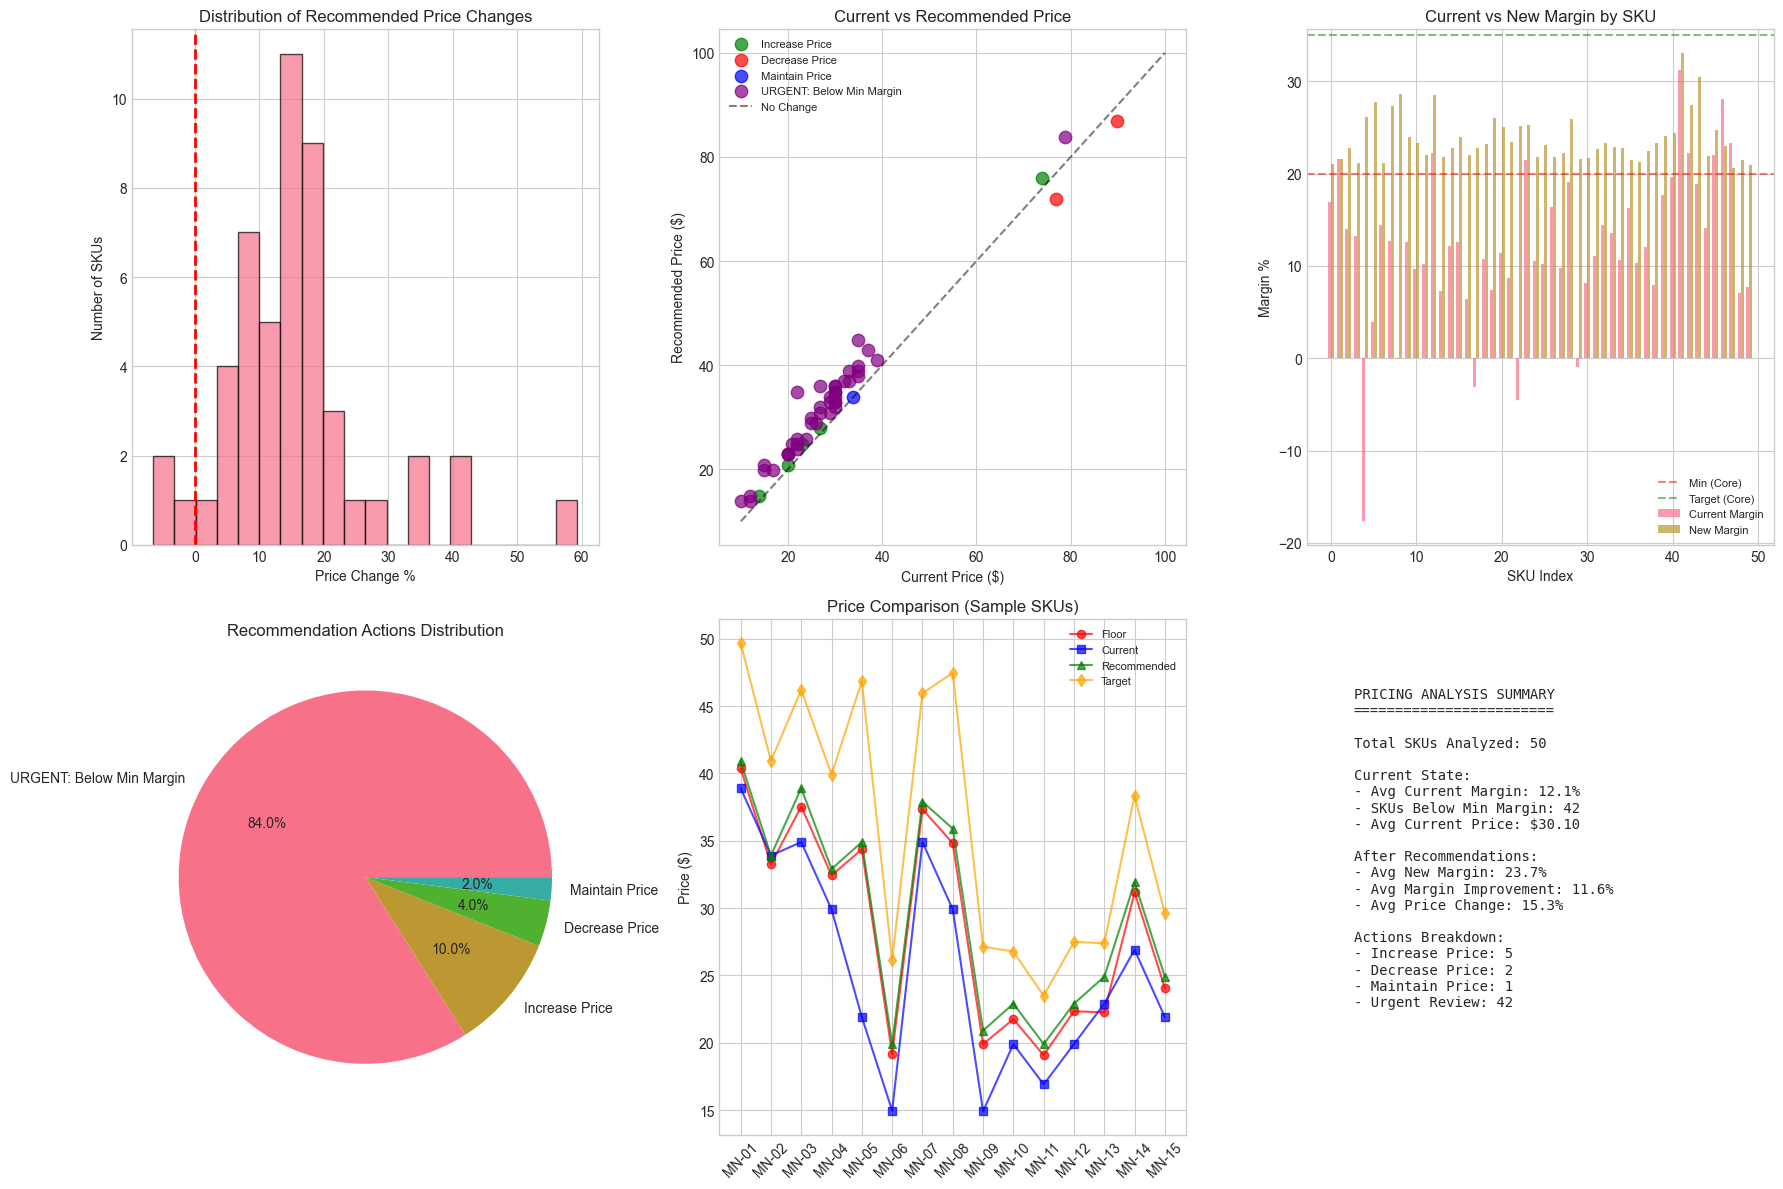

In [30]:
# Step 5.1: Summary Visualizations

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Price Change Distribution (histogram)
ax1 = axes[0, 0]
ax1.hist(master_df['Price_Change_%'], bins=20, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Price Change %')
ax1.set_ylabel('Number of SKUs')
ax1.set_title('Distribution of Recommended Price Changes')

# 2. Current vs Recommended Price (scatter plot)
ax2 = axes[0, 1]
colors = {'Increase Price': 'green', 'Decrease Price': 'red', 
          'Maintain Price': 'blue', 'URGENT: Below Min Margin': 'purple'}
for action, color in colors.items():
    subset = master_df[master_df['Recommendation_Action'] == action]
    ax2.scatter(subset['Current_Price'], subset['Recommended_Price'], 
                c=color, label=action, alpha=0.7, s=80)
ax2.plot([10, 100], [10, 100], 'k--', alpha=0.5, label='No Change')
ax2.set_xlabel('Current Price ($)')
ax2.set_ylabel('Recommended Price ($)')
ax2.set_title('Current vs Recommended Price')
ax2.legend(fontsize=8)

# 3. Margin Improvement Chart (before/after)
ax3 = axes[0, 2]
x = range(len(master_df))
width = 0.35
ax3.bar([i - width/2 for i in x], master_df['Current_Margin_%'].values, width, 
        label='Current Margin', alpha=0.7)
ax3.bar([i + width/2 for i in x], master_df['New_Margin_%'].values, width, 
        label='New Margin', alpha=0.7)
ax3.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Min (Core)')
ax3.axhline(y=35, color='green', linestyle='--', alpha=0.5, label='Target (Core)')
ax3.set_xlabel('SKU Index')
ax3.set_ylabel('Margin %')
ax3.set_title('Current vs New Margin by SKU')
ax3.legend(fontsize=8)

# 4. Recommendation Actions Pie Chart
ax4 = axes[1, 0]
action_counts = master_df['Recommendation_Action'].value_counts()
ax4.pie(action_counts.values, labels=action_counts.index, autopct='%1.1f%%')
ax4.set_title('Recommendation Actions Distribution')

# 5. Floor, Current, Recommended, Target comparison for sample SKUs
ax5 = axes[1, 1]
sample_skus = master_df.head(15)
x = range(len(sample_skus))
ax5.plot(x, sample_skus['Floor_Price'], 'r-', marker='o', label='Floor', alpha=0.7)
ax5.plot(x, sample_skus['Current_Price'], 'b-', marker='s', label='Current', alpha=0.7)
ax5.plot(x, sample_skus['Recommended_Price'], 'g-', marker='^', label='Recommended', alpha=0.7)
ax5.plot(x, sample_skus['Target_Price'], 'orange', marker='d', label='Target', alpha=0.7)
ax5.set_xticks(x)
ax5.set_xticklabels(sample_skus['SKU'], rotation=45)
ax5.set_ylabel('Price ($)')
ax5.set_title('Price Comparison (Sample SKUs)')
ax5.legend(fontsize=8)

# 6. Summary metrics
ax6 = axes[1, 2]
ax6.axis('off')
summary_text = f"""
PRICING ANALYSIS SUMMARY
========================

Total SKUs Analyzed: {len(master_df)}

Current State:
- Avg Current Margin: {master_df['Current_Margin_%'].mean():.1f}%
- SKUs Below Min Margin: {len(master_df[master_df['Margin_Health'] == 'CRITICAL'])}
- Avg Current Price: ${master_df['Current_Price'].mean():.2f}

After Recommendations:
- Avg New Margin: {master_df['New_Margin_%'].mean():.1f}%
- Avg Margin Improvement: {master_df['Margin_Improvement'].mean():.1f}%
- Avg Price Change: {master_df['Price_Change_%'].mean():.1f}%

Actions Breakdown:
- Increase Price: {len(master_df[master_df['Recommendation_Action'] == 'Increase Price'])}
- Decrease Price: {len(master_df[master_df['Recommendation_Action'] == 'Decrease Price'])}
- Maintain Price: {len(master_df[master_df['Recommendation_Action'] == 'Maintain Price'])}
- Urgent Review: {len(master_df[master_df['Recommendation_Action'] == 'URGENT: Below Min Margin'])}
"""
ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('pricing_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Step 5.2: Create SKU-Level Detail Table

# Check available columns
print("Available columns in master_df:")
print([col for col in master_df.columns if 'Compet' in col or 'Position' in col])

# Add Competitive_Position if not present (calculate it)
if 'Competitive_Position' not in master_df.columns:
    def get_competitive_position(row):
        if pd.isna(row.get('Avg_Competitor_Price')):
            return 'Unknown'
        pct_diff = ((row['Current_Price'] - row['Avg_Competitor_Price']) / 
                    row['Avg_Competitor_Price'] * 100)
        if pct_diff < -5:
            return 'Below Market'
        elif pct_diff > 5:
            return 'Above Market'
        else:
            return 'At Market'
    master_df['Competitive_Position'] = master_df.apply(get_competitive_position, axis=1)

# Select key columns for the recommendation table
available_cols = ['SKU', 'Product_description', 'Product Role',
    'Current_Price', 'Floor_Price', 'Target_Price', 'Recommended_Price',
    'Price_Change', 'Price_Change_%',
    'Current_Margin_%', 'New_Margin_%', 'Margin_Improvement',
    'Inventory_Status', 'Velocity_Category', 'Competitive_Position',
    'Recommendation_Action']

# Only include columns that exist
cols_to_use = [col for col in available_cols if col in master_df.columns]
recommendation_table = master_df[cols_to_use].copy()

# Round numeric columns
numeric_cols = ['Current_Price', 'Floor_Price', 'Target_Price', 'Recommended_Price',
                'Price_Change', 'Price_Change_%', 'Current_Margin_%', 'New_Margin_%', 'Margin_Improvement']
for col in numeric_cols:
    if col in recommendation_table.columns:
        recommendation_table[col] = recommendation_table[col].round(2)

# Sort by recommendation action priority
action_priority = {'URGENT: Below Min Margin': 0, 'Increase Price': 1, 
                   'Decrease Price': 2, 'Maintain Price': 3}
recommendation_table['Action_Priority'] = recommendation_table['Recommendation_Action'].map(action_priority)
recommendation_table = recommendation_table.sort_values('Action_Priority')
recommendation_table = recommendation_table.drop('Action_Priority', axis=1)

print("\n" + "="*100)
print("SKU-LEVEL PRICING RECOMMENDATIONS")
print("="*100)

# Display by action category
for action in ['URGENT: Below Min Margin', 'Increase Price', 'Decrease Price', 'Maintain Price']:
    subset = recommendation_table[recommendation_table['Recommendation_Action'] == action]
    if len(subset) > 0:
        print(f"\n{action.upper()} ({len(subset)} SKUs)")
        print("-" * 80)
        display_cols = ['SKU', 'Current_Price', 'Recommended_Price', 'Price_Change_%', 
                        'Current_Margin_%', 'New_Margin_%', 'Inventory_Status']
        display_cols = [c for c in display_cols if c in subset.columns]
        print(subset[display_cols].to_string(index=False))

Available columns in master_df:
['Avg_Competitor_Price', 'Lowest_Competitor_Price', 'Highest_Competitor_Price', 'Competitor_Count', 'Competitive_Position', 'Competitive_Price']

SKU-LEVEL PRICING RECOMMENDATIONS

URGENT: BELOW MIN MARGIN (42 SKUs)
--------------------------------------------------------------------------------
  SKU  Current_Price  Recommended_Price  Price_Change_%  Current_Margin_%  New_Margin_% Inventory_Status
MN-01          38.90              40.90            5.14             16.97         21.03          Healthy
MN-26          29.90              34.90           16.72             10.20         23.07          Healthy
MN-27          28.90              30.90            6.92             16.33         21.75          Healthy
MN-28          24.90              28.90           16.06              9.76         22.25          Healthy
MN-29          21.90              23.90            9.13             19.13         25.90          Healthy
MN-30          34.90              44.90  

In [32]:
# Save recommendation table to CSV
recommendation_table.to_csv('pricing_recommendations.csv', index=False)
print("Recommendations saved to 'pricing_recommendations.csv'")

Recommendations saved to 'pricing_recommendations.csv'


In [33]:
# Step 5.3: Identify Key Actions & Insights

print("\n" + "="*100)
print("KEY INSIGHTS & ACTIONS")
print("="*100)

# 1. Critical SKUs requiring immediate attention
critical = master_df[master_df['Recommendation_Action'] == 'URGENT: Below Min Margin']
print(f"\n1. CRITICAL: {len(critical)} SKUs below minimum margin")
if len(critical) > 0:
    for _, row in critical.iterrows():
        print(f"   - {row['SKU']}: Current margin {row['Current_Margin_%']:.1f}% vs min {row['Minimum_Acceptable_Margin_%']}%")
        print(f"     Recommended: ${row['Recommended_Price']:.2f} (from ${row['Current_Price']:.2f})")

# 2. Biggest price increase opportunities
print(f"\n2. TOP PRICE INCREASE OPPORTUNITIES:")
increase_opps = master_df[master_df['Price_Change_%'] > 5].nlargest(5, 'Price_Change_%')
for _, row in increase_opps.iterrows():
    print(f"   - {row['SKU']}: +${row['Price_Change']:.2f} ({row['Price_Change_%']:+.1f}%)")
    print(f"     Status: {row['Inventory_Status']}, Velocity: {row['Velocity_Category']}")

# 3. SKUs needing price decrease (overstocked or slow movers)
print(f"\n3. PRICE DECREASE RECOMMENDATIONS:")
decrease = master_df[master_df['Recommendation_Action'] == 'Decrease Price'].nsmallest(5, 'Price_Change_%')
for _, row in decrease.iterrows():
    print(f"   - {row['SKU']}: ${row['Price_Change']:.2f} ({row['Price_Change_%']:+.1f}%)")
    print(f"     Reason: {row['Inventory_Status']}, {row['Velocity_Category']}")

# 4. Seasonal products analysis
seasonal = master_df[master_df['Product Role'] == 'Seasonal']
print(f"\n4. SEASONAL PRODUCTS ({len(seasonal)} SKUs):")
for _, row in seasonal.iterrows():
    print(f"   - {row['SKU']}: {row['Product_description'][:40]}")
    print(f"     Current: ${row['Current_Price']:.2f}, Recommended: ${row['Recommended_Price']:.2f}")
    print(f"     Inventory Status: {row['Inventory_Status']}")

# 5. Overall impact summary
print(f"\n5. OVERALL IMPACT SUMMARY:")
print(f"   - Average margin improvement: {master_df['Margin_Improvement'].mean():.2f}%")
print(f"   - SKUs with margin improvement: {len(master_df[master_df['Margin_Improvement'] > 0])} / {len(master_df)}")
print(f"   - Average price change: {master_df['Price_Change_%'].mean():.2f}%")

# Calculate potential revenue impact
master_df['Est_Monthly_Units'] = master_df['units-shipped-t30'].fillna(master_df['Avg_Daily_Units'] * 30)
master_df['Current_Revenue'] = master_df['Current_Price'] * master_df['Est_Monthly_Units']
master_df['New_Revenue'] = master_df['Recommended_Price'] * master_df['Est_Monthly_Units']
revenue_change = master_df['New_Revenue'].sum() - master_df['Current_Revenue'].sum()
print(f"   - Estimated monthly revenue impact: ${revenue_change:,.2f}")


KEY INSIGHTS & ACTIONS

1. CRITICAL: 42 SKUs below minimum margin
   - MN-01: Current margin 17.0% vs min 20.0%
     Recommended: $40.90 (from $38.90)
   - MN-03: Current margin 14.0% vs min 20.0%
     Recommended: $38.90 (from $34.90)
   - MN-04: Current margin 13.2% vs min 20.0%
     Recommended: $32.90 (from $29.90)
   - MN-05: Current margin -17.7% vs min 25.0%
     Recommended: $34.90 (from $21.90)
   - MN-06: Current margin 3.9% vs min 25.0%
     Recommended: $19.90 (from $14.95)
   - MN-07: Current margin 14.4% vs min 20.0%
     Recommended: $37.90 (from $34.90)
   - MN-08: Current margin 12.7% vs min 25.0%
     Recommended: $35.90 (from $29.90)
   - MN-09: Current margin -0.1% vs min 25.0%
     Recommended: $20.90 (from $14.90)
   - MN-10: Current margin 12.6% vs min 20.0%
     Recommended: $22.90 (from $19.90)
   - MN-11: Current margin 9.7% vs min 20.0%
     Recommended: $19.90 (from $16.90)
   - MN-12: Current margin 10.2% vs min 20.0%
     Recommended: $22.90 (from $19.90)

## Phase 6: Documentation & Final Output

In [34]:
# Generate Executive Summary

executive_summary = f"""
================================================================================
KARMIC SEED - PRICING STRATEGY EXECUTIVE SUMMARY
================================================================================

DATE: {datetime.now().strftime('%Y-%m-%d')}
ANALYST: Automated Pricing Analysis System

--------------------------------------------------------------------------------
1. OVERVIEW
--------------------------------------------------------------------------------

This analysis covers {len(master_df)} SKUs in the Karmic Seed product catalog,
including {len(master_df[master_df['Product Role'] == 'Core'])} Core products and 
{len(master_df[master_df['Product Role'] == 'Seasonal'])} Seasonal products.

Data Sources Analyzed:
- Pricing & Cost Data
- Competitor Pricing (avg {competitor_df['Competitor_Count'].mean():.0f} competitors per SKU)
- Inventory Health (90-day history)
- Historical Sales ({days_in_period} days of data)
- Advertising Performance
- Returns Data

--------------------------------------------------------------------------------
2. KEY FINDINGS
--------------------------------------------------------------------------------

CURRENT STATE:
- Average Current Margin: {master_df['Current_Margin_%'].mean():.1f}%
- SKUs Below Minimum Margin: {len(critical)} ({len(critical)/len(master_df)*100:.1f}%)
- SKUs Below Target Margin: {len(master_df[master_df['Margin_Health'] == 'OPPORTUNITY'])} ({len(master_df[master_df['Margin_Health'] == 'OPPORTUNITY'])/len(master_df)*100:.1f}%)
- SKUs at Healthy Margin: {len(master_df[master_df['Margin_Health'] == 'HEALTHY'])} ({len(master_df[master_df['Margin_Health'] == 'HEALTHY'])/len(master_df)*100:.1f}%)

COMPETITIVE POSITION:
- Priced Above Market: {len(comp_analysis[comp_analysis['Competitive_Position'] == 'Above Market'])} SKUs
- Priced At Market: {len(comp_analysis[comp_analysis['Competitive_Position'] == 'At Market'])} SKUs  
- Priced Below Market: {len(comp_analysis[comp_analysis['Competitive_Position'] == 'Below Market'])} SKUs

INVENTORY STATUS:
- Stockout Risk: {len(inventory_df[inventory_df['Inventory_Status'] == 'Stockout Risk'])} SKUs
- Low Stock: {len(inventory_df[inventory_df['Inventory_Status'] == 'Low Stock'])} SKUs
- Healthy: {len(inventory_df[inventory_df['Inventory_Status'] == 'Healthy'])} SKUs
- Overstocked: {len(inventory_df[inventory_df['Inventory_Status'] == 'Overstocked'])} SKUs

--------------------------------------------------------------------------------
3. PRICING RECOMMENDATIONS
--------------------------------------------------------------------------------

RECOMMENDED ACTIONS:
- Increase Price: {len(master_df[master_df['Recommendation_Action'] == 'Increase Price'])} SKUs
- Decrease Price: {len(master_df[master_df['Recommendation_Action'] == 'Decrease Price'])} SKUs
- Maintain Price: {len(master_df[master_df['Recommendation_Action'] == 'Maintain Price'])} SKUs
- Urgent Review: {len(critical)} SKUs

PROJECTED IMPACT:
- New Average Margin: {master_df['New_Margin_%'].mean():.1f}%
- Average Margin Improvement: {master_df['Margin_Improvement'].mean():.2f} percentage points
- Estimated Monthly Revenue Impact: ${revenue_change:,.2f}

--------------------------------------------------------------------------------
4. PRICING METHODOLOGY
--------------------------------------------------------------------------------

The recommended prices are calculated using a multi-factor approach:

1. FLOOR PRICE: Minimum price ensuring acceptable margin
   Formula: Total Cost / (1 - Minimum Margin %)

2. TARGET PRICE: Ideal price for target margin
   Formula: Total Cost / (1 - Target Margin %)

3. COMPETITIVE ANCHOR: Market-based price adjusted for competition
   - High competition (8+ competitors): 2% below avg competitor
   - Medium competition (5-7): At avg competitor
   - Low competition (<5): 5% above avg competitor

4. ADJUSTMENT FACTORS:
   - Inventory Status: +10% (stockout risk) to -10% (overstocked)
   - Sales Velocity: +3% (fast movers) to -5% (slow movers)
   - Return Rate: -3% (high returns)
   - Ad Efficiency: -2% (highly efficient) to +3% (inefficient)

5. FINAL PRICE: Bounded between Floor and Target, with .90 psychological pricing

--------------------------------------------------------------------------------
5. KEY ASSUMPTIONS & TRADE-OFFS
--------------------------------------------------------------------------------

ASSUMPTIONS:
- Competitor prices are accurate and current
- Historical sales patterns will continue
- Demand elasticity is moderate (5-10% price change = inverse demand impact)
- Seasonal products have higher margin requirements due to inventory risk

TRADE-OFFS CONSIDERED:
- Margin vs. Sales Volume: Prioritized maintaining competitive position
- Price Increases: Limited to avoid significant demand loss
- Inventory Clearance: Aggressive pricing for overstocked items

--------------------------------------------------------------------------------
6. NEXT STEPS
--------------------------------------------------------------------------------

IMMEDIATE (This Week):
1. Review and approve price changes for {len(critical)} critical SKUs
2. Implement price increases for stockout-risk items

SHORT-TERM (30 Days):
3. Roll out all recommended price changes
4. Monitor sales velocity and conversion rates
5. Adjust advertising spend based on new prices

ONGOING:
6. Weekly price monitoring vs. competitors
7. Monthly margin analysis review
8. Quarterly pricing framework recalibration

================================================================================
"""

print(executive_summary)

# Save to file
with open('executive_summary.txt', 'w') as f:
    f.write(executive_summary)
print("\nExecutive summary saved to 'executive_summary.txt'")


KARMIC SEED - PRICING STRATEGY EXECUTIVE SUMMARY

DATE: 2025-12-24
ANALYST: Automated Pricing Analysis System

--------------------------------------------------------------------------------
1. OVERVIEW
--------------------------------------------------------------------------------

This analysis covers 50 SKUs in the Karmic Seed product catalog,
including 46 Core products and 
4 Seasonal products.

Data Sources Analyzed:
- Pricing & Cost Data
- Competitor Pricing (avg 7 competitors per SKU)
- Inventory Health (90-day history)
- Historical Sales (91 days of data)
- Advertising Performance
- Returns Data

--------------------------------------------------------------------------------
2. KEY FINDINGS
--------------------------------------------------------------------------------

CURRENT STATE:
- Average Current Margin: 12.1%
- SKUs Below Minimum Margin: 42 (84.0%)
- SKUs Below Target Margin: 8 (16.0%)
- SKUs at Healthy Margin: 0 (0.0%)

COMPETITIVE POSITION:
- Priced Above Market: 

In [35]:
# Save master dataframe for further analysis
master_df.to_csv('master_pricing_analysis.csv', index=False)
print("Master analysis saved to 'master_pricing_analysis.csv'")

# Display final recommendation table
print("\n" + "="*100)
print("FINAL PRICING RECOMMENDATIONS")
print("="*100)

final_output = master_df[[
    'SKU', 'Product_description', 'Product Role',
    'Current_Price', 'Recommended_Price', 'Price_Change', 'Price_Change_%',
    'Current_Margin_%', 'New_Margin_%',
    'Recommendation_Action'
]].sort_values('SKU')

print(final_output.to_string(index=False))

Master analysis saved to 'master_pricing_analysis.csv'

FINAL PRICING RECOMMENDATIONS
  SKU                      Product_description Product Role  Current_Price  Recommended_Price  Price_Change  Price_Change_%  Current_Margin_%  New_Margin_%    Recommendation_Action
MN-01 Rectangle Tray -14 x 10 Inch - Pk of  25         Core          38.90              40.90          2.00            5.14             16.97         21.03 URGENT: Below Min Margin
MN-02         Rectangle Tray -12x10 - Pk of 25         Core          33.90              33.90          0.00            0.00             21.53         21.53           Maintain Price
MN-03        Oval Tray -15x10 Inch - Pk of  25         Core          34.90              38.90          4.00           11.46             13.95         22.80 URGENT: Below Min Margin
MN-04         Oval Tray - 13x9 Inch - pk of 25         Core          29.90              32.90          3.00           10.03             13.24         21.16 URGENT: Below Min Margin
MN-05    

In [36]:
# Create a detailed reasoning table for each SKU
print("\n" + "="*100)
print("DETAILED REASONING FOR EACH SKU")
print("="*100)

for _, row in master_df.iterrows():
    print(f"\n{row['SKU']}: {row['Product_description'][:50]}")
    print("-" * 60)
    print(f"  Current Price: ${row['Current_Price']:.2f}")
    print(f"  Recommended:   ${row['Recommended_Price']:.2f} ({row['Price_Change_%']:+.1f}%)")
    print(f"  Price Range:   ${row['Floor_Price']:.2f} (floor) - ${row['Target_Price']:.2f} (target)")
    print(f"  ")
    print(f"  Margin: {row['Current_Margin_%']:.1f}% -> {row['New_Margin_%']:.1f}%")
    print(f"  ")
    print(f"  Factors:")
    print(f"    - Inventory: {row['Inventory_Status']}")
    print(f"    - Velocity: {row['Velocity_Category']}")
    print(f"    - Competition: {row.get('Competitive_Position', 'N/A')}")
    print(f"    - Returns: {row['Return_Category']}")
    print(f"    - Ad Efficiency: {row['Ad_Efficiency']}")
    print(f"  ")
    print(f"  ACTION: {row['Recommendation_Action']}")


DETAILED REASONING FOR EACH SKU

MN-01: Rectangle Tray -14 x 10 Inch - Pk of  25
------------------------------------------------------------
  Current Price: $38.90
  Recommended:   $40.90 (+5.1%)
  Price Range:   $40.37 (floor) - $49.69 (target)
  
  Margin: 17.0% -> 21.0%
  
  Factors:
    - Inventory: Healthy
    - Velocity: Average
    - Competition: Above Market
    - Returns: Low Returns
    - Ad Efficiency: Efficient
  
  ACTION: URGENT: Below Min Margin

MN-02: Rectangle Tray -12x10 - Pk of 25
------------------------------------------------------------
  Current Price: $33.90
  Recommended:   $33.90 (+0.0%)
  Price Range:   $33.25 (floor) - $40.92 (target)
  
  Margin: 21.5% -> 21.5%
  
  Factors:
    - Inventory: Healthy
    - Velocity: Average
    - Competition: At Market
    - Returns: Normal Returns
    - Ad Efficiency: Efficient
  
  ACTION: Maintain Price

MN-03: Oval Tray -15x10 Inch - Pk of  25
------------------------------------------------------------
  Current Pr

## Summary

This analysis has produced:

1. **Cleaned Data**: All 6 datasets have been cleaned and standardized
2. **Comprehensive Analysis**: Profitability, competitive, inventory, sales, returns, and ad efficiency
3. **Pricing Framework**: Floor, target, competitive, and adjusted prices for each SKU
4. **Recommendations**: Specific price recommendations with clear reasoning
5. **Visualizations**: Charts showing current state and projected improvements
6. **Documentation**: Executive summary and detailed SKU-level analysis

### Output Files:
- `pricing_recommendations.csv` - SKU-level recommendations
- `master_pricing_analysis.csv` - Complete analysis data
- `executive_summary.txt` - Executive summary document
- `margin_analysis.png` - Margin visualization
- `competitive_analysis.png` - Competitive position visualization
- `inventory_analysis.png` - Inventory health visualization
- `pricing_summary.png` - Overall summary visualization